In [25]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.model_selection import train_test_split
import re
from tensorflow.keras.optimizers import Adam
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report


In [26]:
def load_training_data():
    try:
        df = pd.read_csv('training_dataset.csv')
    except Exception as e:
        print(f"Error : {e}")
        df = None
    finally:
        return df

In [27]:
# Function to extract latitude and longitude
def extract_lat_lon(coord):

    """
    This method is spliting geo_loc feature into lat and lon.
    """
    
    try:
        matches = re.findall(r"[-+]?\d*\.\d+|\d+", str(coord))  # Extract all numeric values
        if len(matches) == 2:
            return float(matches[0]), float(matches[1])  # Convert to float
        return None, None  # Return None if values are missing
    except Exception as e:
        print(f"Error in extract_lat_lon : {e} ")
        return None, None 

In [28]:

def preprocessing(df):
    

    drop_columns = [
    'transaction_id', 'user_id', 'merchant_id', 'device_id', 
    'ip_address', 'browser_fingerprint', 'currency','risk_score', 'status', 'is_new_device'
    ]
    try:
        df_clean = df.drop(columns=drop_columns, axis=1)
        df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
        df_clean['hour'] = df_clean['timestamp'].dt.hour
        df_clean['day_of_week'] = df_clean['timestamp'].dt.dayofweek
        df_clean['is_weekend'] = df_clean['timestamp'].dt.weekday // 5
        df_clean[['lat', 'lon']] = df_clean['geolocation'].apply(lambda x: pd.Series(extract_lat_lon(x)))
    except Exception as e:
        print(f"Error preprocessing to split features into more :{e} ")

    try:
        df_clean.dropna(inplace=True)
        df_clean.drop_duplicates(inplace=True)
    except Exception as e:
        print(f"Error preprocessing to drop null :{e} ")
    
    try:
        merchant_category = {"Groceries" : 0,  'Bank' : 1, 'Electronics' : 2,  'ATM' : 3, 'Restaurant' : 4, 'Luxury Goods' : 5}
        df_clean['merchant_category'] = df_clean['merchant_category'].map(merchant_category)

        transaction_type = {'Refund' : 0, 'Transfer' : 1, 'Purchase' : 2, 'Withdrawal' : 3}

        df_clean['transaction_type'] = df_clean['transaction_type'].map(transaction_type)
        
        df_clean = df_clean.drop(['timestamp', 'geolocation'], axis=1)
        df_clean['transaction_ratio'] = df_clean['amount'] / df_clean['balance_before']
    except Exception as e:
        print(f"Error preprocessing to encode categorical features  :{e} ")
    
    try:
        scaler = MinMaxScaler()
        df_clean['amount'] = np.log1p(df_clean['amount'])
        columns_to_normalize = ['balance_before', 'amount', 'transaction_velocity', 'geo_velocity', 'lat', 'lon', 'transaction_ratio']
        df_clean[columns_to_normalize] = scaler.fit_transform(df_clean[columns_to_normalize])
    except Exception as e:
        print(f"Error preprocessing to Normalize features :{e} ")
    
    return df_clean

In [29]:
def find_corr_and_drop_less_valuable_feature(df_clean):

    # Assuming your DataFrame is named df
    correlation_matrix = df_clean.corr()

    # Extract correlation with 'is_fraudulent'
    correlation_with_target = correlation_matrix['is_fraudulent'].abs().sort_values(ascending=False)

    print(correlation_with_target)
    # Assuming you want to drop columns with correlation < 0.1
    columns_to_drop = correlation_with_target[correlation_with_target < 0.1].index

    # Drop these columns from the DataFrame
    df_clean = df_clean.drop(columns=columns_to_drop)

    print("Columns dropped:", columns_to_drop)
    print("Remaining columns:", df_clean.columns)

    return df_clean


In [30]:

def split_data(df_clean):

    Y = df_clean['is_fraudulent']
    X = df_clean.drop(columns=['is_fraudulent'], axis=1)   
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.1, random_state=42, stratify=Y)

    # Print dataset sizes
    print(f"Training Set: {X_train.shape[0]} rows")
    print(f"Testing Set: {X_test.shape[0]} rows")  

    return X_train, X_test, y_train, y_test 

In [31]:
# Define the ANN model
def build_ann(X_train):
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),  # Input layer
        layers.BatchNormalization(),  # Normalize activations
        layers.Dropout(0.7),  # Reduce overfitting

        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.7),

        layers.Dense(16, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.7),

        layers.Dense(1, activation='sigmoid')  # Output layer (Binary Classification)
    ])
    
    # Compile model
    model.compile(optimizer=Adam(0.0001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [36]:
def train_model(X_train, y_train, model):

    # Early stopping to prevent overfitting
    early_stop = callbacks.EarlyStopping(monitor='val_loss', restore_best_weights=True)

    # Train the model
    history = model.fit(X_train, y_train, epochs=10, batch_size=128, validation_split=0.2, callbacks=[early_stop], verbose=1)
    model.save("trained_model_weights/fraud_detection_model_latest.h5")  # Saves in HDF5 format
    return history 

In [ ]:
def graphs(history, model, X_test, y_test):

    # Plot training history
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title('Model Loss Over Epochs')
    plt.savefig("model_performance_graphs/model_loss.png")
    plt.show()

    # Plot training history
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['accuracy'], label='Train Loss')
    plt.plot(history.history['val_accuracy'], label='Val Loss')
    plt.legend()
    plt.title('Model Loss Over Epochs')
    plt.savefig("model_performance_graphs/model_training.png")
    plt.show()

    # Predict fraud probabilities
    y_pred = model.predict(X_test)
    y_pred_labels = (y_pred > 0.5).astype(int)  # Convert to binary labels

    # Confusion matrix

    print("Classification Report:\n", classification_report(y_test, y_pred_labels))

    sns.heatmap(confusion_matrix(y_test, y_pred_labels), annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig("model_performance_graphs/confusion_matrix.png")
    plt.show()

In [40]:
def compute_fraud_rate(df_old, df_new):
    # Compute fraud rate in old & new data
    prev_fraud_rate = df_old["is_fraudulent"].mean()  # % of transactions predicted as fraud
    new_fraud_rate = df_new["is_fraudulent"].mean()

    print(f"Old Fraud Rate: {prev_fraud_rate:.2%}")
    print(f"New Fraud Rate: {new_fraud_rate:.2%}")
    
    change_rate = abs(prev_fraud_rate - new_fraud_rate)
    # Alert if fraud detection rate changes significantly
    if change_rate > 0.05:  # If drift > 5%
        print("🚨 ALERT: Significant change in fraud detection rate!")
    return change_rate

In [38]:
def run_training_pipeline():

   try:
      df = load_training_data()
      df_clean = preprocessing(df)
      df_clean = find_corr_and_drop_less_valuable_feature(df_clean)
      X_train, X_test, y_train, y_test  = split_data(df_clean)
      model = build_ann(X_train)
      history = train_model(X_train, y_train, model)
      graphs(history, model, X_test, y_test)
   except Exception as e:
      print(f"Error in run_training_pipeline : {e}")


In [ ]:
from scipy.stats import ks_2samp

def check_feature_drift(df_prev, df_new):
    features = ["amount", "transaction_velocity", "transaction_ratio"]
    feature_p_value = {}
    for feature in features:

        stat, p_value = ks_2samp(df_prev[feature], df_new[feature])
        print(f"Feature: {feature} | KS-Test p-value: {p_value:.5f}")
        
        feature_p_value[feature] = p_value
        if p_value < 0.05:
            print(f"🚨 ALERT: Feature '{feature}' has drifted!")
        else:
            print(f"✅ Feature '{feature}' is stable.")

# Check for drift in multiple features
# for feature in ["amount", "transaction_velocity", "transaction_ratio"]:
check_feature_drift()

is_fraudulent           1.000000
lon                     0.985010
merchant_category       0.842679
amount                  0.610847
transaction_ratio       0.577774
hour                    0.310750
transaction_type        0.301717
transaction_velocity    0.167997
lat                     0.028193
balance_before          0.001566
geo_velocity            0.000614
is_weekend              0.000523
day_of_week             0.000088
Name: is_fraudulent, dtype: float64
Columns dropped: Index(['lat', 'balance_before', 'geo_velocity', 'is_weekend', 'day_of_week'], dtype='object')
Remaining columns: Index(['transaction_type', 'amount', 'merchant_category', 'is_fraudulent',
       'transaction_velocity', 'hour', 'lon', 'transaction_ratio'],
      dtype='object')
Training Set: 450000 rows
Testing Set: 50000 rows


/Users/UZAIR/Desktop/fraud_detection/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.5904 - loss: 0.7562 - val_accuracy: 0.9921 - val_loss: 0.1727
Epoch 2/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9059 - loss: 0.2544 - val_accuracy: 1.0000 - val_loss: 0.0087
Epoch 3/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9751 - loss: 0.0837 - val_accuracy: 1.0000 - val_loss: 6.5560e-04
Epoch 4/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9883 - loss: 0.0399 - val_accuracy: 1.0000 - val_loss: 6.8494e-05
Epoch 5/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9935 - loss: 0.0221 - val_accuracy: 1.0000 - val_loss: 8.3598e-06
Epoch 6/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9952 - loss: 0.0152 - val_accuracy: 1.0000 - val_loss: 1.3593e-06
Epoch 7/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9966 - loss: 0.0106 - val_accuracy: 1.0000 - val_loss: 2.4140e-07
Epoch 8/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9

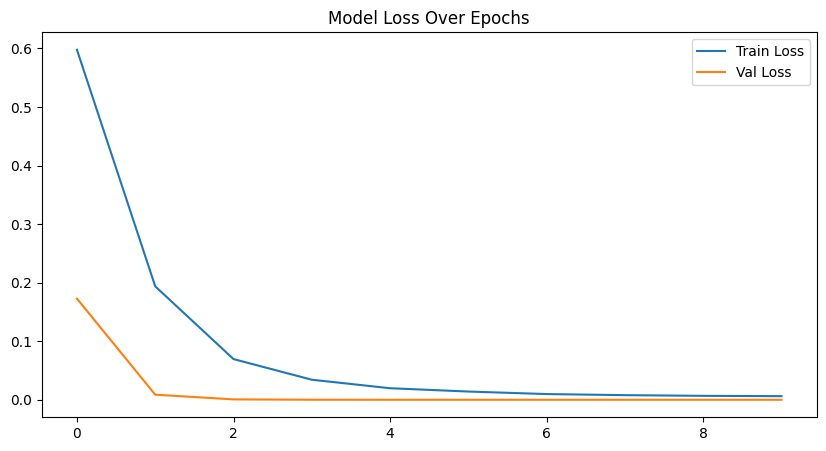

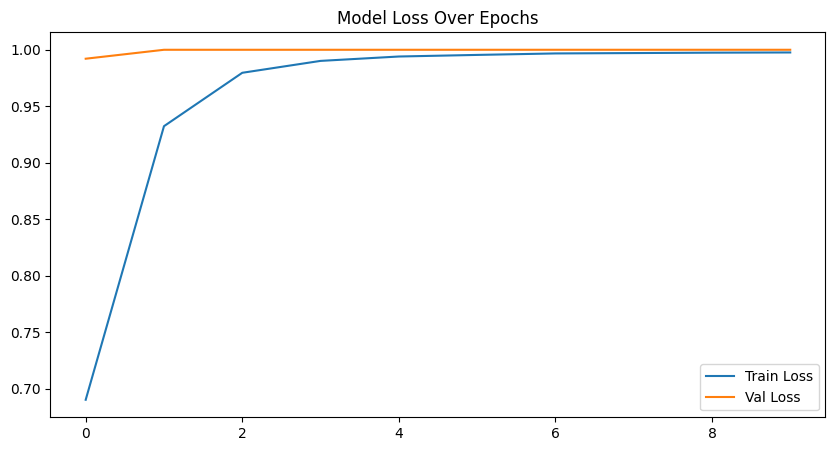

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     25000
           1       1.00      1.00      1.00     25000

    accuracy                           1.00     50000
   macro avg       1.00      1.00      1.00     50000
weighted avg       1.00      1.00      1.00     50000



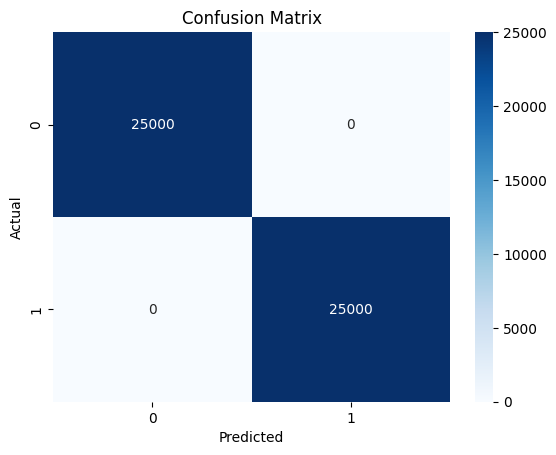

In [39]:
run_training_pipeline()

In [42]:
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp
from sklearn.metrics import accuracy_score

# Load your dataset
# df = pd.read_csv("your_data.csv")  # Uncomment if loading from a file

# Define the function to find the best KS threshold
def find_best_threshold(df):
    feature_cols = ['transaction_type', 'amount', 'merchant_category',
                    'transaction_velocity', 'hour', 'lon', 'transaction_ratio']
    
    ks_scores = {}
    for col in feature_cols:
        ks_stat, _ = ks_2samp(df[df['is_fraudulent'] == 1][col], df[df['is_fraudulent'] == 0][col])
        ks_scores[col] = ks_stat

    best_threshold = 0
    best_accuracy = 0

    for threshold in np.linspace(0.05, max(ks_scores.values()), 100):
        predictions = {col: (ks_scores[col] > threshold) for col in feature_cols}
        
        # Convert the predictions into binary labels
        predicted_labels = np.array([1 if any(predictions.values()) else 0] * len(df))

        # Calculate accuracy
        accuracy = accuracy_score(df['is_fraudulent'], predicted_labels)

        # Update the best threshold
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_threshold = threshold

    return best_threshold, best_accuracy

# Call the function
best_threshold, best_accuracy = find_best_threshold(df)

print(f"Optimal KS Threshold: {best_threshold:.4f}")
print(f"Best Accuracy: {best_accuracy:.4f}")


Optimal KS Threshold: 0.0500
Best Accuracy: 0.5000
